# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/whozahm3d/flyrank-ml-internship/blob/main/work/notebooks/w05_model.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:

import os, sys, subprocess
IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/whozahm3d/flyrank-ml-internship"
REPO_DIR = "flyrank-ml-internship"
if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)

## 1. Method choice and why

**Question shape:** this is a yes/no question with an observed label —
`trend_direction == "down"` — not a ranking or clustering problem. Per the
skill's method table, that shape starts with **Logistic Regression**, then
escalates to **Random Forest** only if the extra complexity actually earns
its place on the same comparison table.

**Why Logistic Regression first, not straight to Random Forest:**
- It's readable — every feature gets one coefficient, sign and magnitude
  both interpretable, which matters for Step 4's "what does it lean on"
  requirement and for sanity-checking against leakage (a suspiciously huge
  coefficient is as suspicious as a suspiciously perfect score).
- The Week-4 baseline itself is a two-signal linear rule (`score_row()`).
  A linear model is the natural next step up from a hand-built linear rule
  — it should tell me whether *more* signals combined linearly beat two
  signals combined by hand, before reaching for a nonlinear model to
  explain the gap away.
- Random Forest gets a fair shot in Step 3 *only if* Logistic Regression
  underperforms or clearly can't capture something in the data (e.g. the
  known CTR-vs-position interaction, which only holds in a *band*, not
  linearly across the full position range — exactly the kind of thing a
  tree can pick up that a linear model can't without an engineered
  interaction term).

**What this step's code needs to establish before any modeling:**
1. Load the same `content_refresh_anonymized.csv` the baseline used.
2. Print the label base rate (`trend_direction == "down"`), since Week 4's
   own volume-bucket table already showed this sits around 51-59% depending
   on the slice — a model has to clear that bar by more than the base rate
   alone, or it isn't adding anything.
3. Confirm the leakage boundary carried forward from every prior notebook:
   `trend_direction` and `trend_pct` are the label and its direct
   precursor — **never features**. List candidate feature columns
   explicitly here, with those (and the pseudonym ID columns) excluded, so
   Step 3's feature set traces back to a decision made here, not a
   silent default.

In [2]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

import pandas as pd
import numpy as np

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

DATA_PATH = "data/raw/content_refresh_anonymized.csv"
df = pd.read_csv(DATA_PATH)
print(f"rows: {len(df):,}  cols: {df.shape[1]}")

rows: 30,000  cols: 44


In [6]:
# --- Label base rate ---
label = (df["trend_direction"] == "down").astype(int)
print("Label base rate (trend_direction == 'down'):")
print(f"  positive (down): {label.mean():.3f}  (n={label.sum():,})")
print(f"  negative (not down): {1 - label.mean():.3f}  (n={(1 - label).sum():,})")
print("\nFull trend_direction distribution:")
print(df["trend_direction"].value_counts())

Label base rate (trend_direction == 'down'):
  positive (down): 0.542  (n=16,262)
  negative (not down): 0.458  (n=13,738)

Full trend_direction distribution:
trend_direction
down      16262
stable     5962
up         4388
new        2236
flat       1152
Name: count, dtype: int64


In [5]:
# --- Leakage boundary: columns that can NEVER be features ---
label_derived_cols = ["trend_direction", "trend_pct"]  # label + its direct precursor
id_cols = ["content_id", "client_id"]  # pseudonyms — grouping/splitting only, never features

print(f"Excluded as label-derived (never features): {label_derived_cols}")
print(f"Excluded as ID/pseudonym (grouping only, never features): {id_cols}")

Excluded as label-derived (never features): ['trend_direction', 'trend_pct']
Excluded as ID/pseudonym (grouping only, never features): ['content_id', 'client_id']


In [7]:
# --- Candidate feature columns: everything else ---
excluded = set(label_derived_cols + id_cols)
candidate_features = [c for c in df.columns if c not in excluded]
print(f"Candidate feature columns ({len(candidate_features)} of {df.shape[1]} total columns):")
print(candidate_features)

Candidate feature columns (40 of 44 total columns):
['search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier']


In [8]:
# --- Quick dtype + missingness pass on candidates, to flag fillna(0) risk early ---
missing_report = (
    df[candidate_features]
    .isna()
    .mean()
    .sort_values(ascending=False)
)
print("Missingness among candidate features (top 10, if any):")
print(missing_report.head(10).round(3))

Missingness among candidate features (top 10, if any):
provider_used        0.715
word_count           0.257
word_count_tier      0.257
char_count           0.257
char_count_tier      0.257
model_used           0.191
competition_level    0.087
search_volume        0.082
competition          0.082
cpc                  0.082
dtype: float64


In [9]:
# --- Leakage proxy check: do the *_last_30d / *_prev_30d columns reconstruct trend_pct? ---
window_cols = [
    "impressions_last_30d", "clicks_last_30d", "sessions_last_30d",
    "impressions_prev_30d", "clicks_prev_30d", "sessions_prev_30d",
]

check = df[window_cols + ["trend_pct"]].dropna()
print(f"rows with all window cols + trend_pct present: {len(check):,}\n")

print("Correlation with trend_pct:")
print(check[window_cols].corrwith(check["trend_pct"]).round(3))

rows with all window cols + trend_pct present: 26,612

Correlation with trend_pct:
impressions_last_30d    0.097
clicks_last_30d         0.006
sessions_last_30d       0.008
impressions_prev_30d   -0.010
clicks_prev_30d        -0.004
sessions_prev_30d      -0.005
dtype: float64


In [11]:
# A naive last-vs-prev pct change on each metric, compared directly to trend_pct
for metric in ["clicks", "sessions", "impressions"]:
    last, prev = f"{metric}_last_30d", f"{metric}_prev_30d"
    with np.errstate(divide="ignore", invalid="ignore"):
        naive_pct = (check[last] - check[prev]) / check[prev].replace(0, np.nan) * 100
    corr = naive_pct.corr(check["trend_pct"])
    print(f"naive pct-change on {metric}: corr with trend_pct = {corr:.3f}")

naive pct-change on clicks: corr with trend_pct = 0.091
naive pct-change on sessions: corr with trend_pct = 0.052
naive pct-change on impressions: corr with trend_pct = 1.000


In [12]:
# --- Full leakage sweep: correlate every numeric candidate feature with trend_pct ---
numeric_candidates = df[candidate_features].select_dtypes(include=[np.number]).columns.tolist()

sweep = df[numeric_candidates + ["trend_pct"]].dropna()
print(f"rows used for sweep (complete cases across {len(numeric_candidates)} numeric candidates + trend_pct): {len(sweep):,}\n")

corrs = sweep[numeric_candidates].corrwith(sweep["trend_pct"]).sort_values(key=lambda s: s.abs(), ascending=False)
print("All numeric candidate features, sorted by |correlation| with trend_pct:")
print(corrs.round(3).to_string())

rows used for sweep (complete cases across 29 numeric candidates + trend_pct): 17,917

All numeric candidate features, sorted by |correlation| with trend_pct:
impressions_last_30d      0.120
avg_position              0.040
impressions_90d           0.035
days_with_impressions    -0.031
days_since_last_update   -0.018
content_age_days         -0.014
engagement_rate           0.013
competition               0.012
age_tier_order           -0.012
sessions_last_30d         0.011
ctr                       0.011
clicks_last_30d           0.010
impressions_prev_30d     -0.008
word_count               -0.006
scroll_events_90d        -0.005
sessions_prev_30d        -0.005
char_count               -0.004
scroll_rate               0.004
engaged_sessions_90d      0.004
days_with_sessions       -0.003
clicks_prev_30d          -0.003
ai_sessions_90d          -0.002
ai_traffic_pct           -0.002
pageviews_90d             0.001
users_90d                -0.001
search_volume             0.001
sessions_

In [13]:
# Flag anything above a conservative threshold for a closer look
suspicious = corrs[corrs.abs() > 0.15]
print(f"Features above |corr| 0.15 (candidates for exclusion or closer inspection): {len(suspicious)}")
print(suspicious.round(3).to_string() if len(suspicious) else "  none")

Features above |corr| 0.15 (candidates for exclusion or closer inspection): 0
  none


In [14]:
# --- Isolate impressions_prev_30d and impressions_last_30d individually (already known, restated for the record) ---
print("For the record — isolated (not paired) correlations already found:")
print(f"  impressions_last_30d alone: {corrs.get('impressions_last_30d'):.3f}")
print(f"  impressions_prev_30d alone: {corrs.get('impressions_prev_30d'):.3f}")

For the record — isolated (not paired) correlations already found:
  impressions_last_30d alone: 0.120
  impressions_prev_30d alone: -0.008


In [15]:
# --- Check the 90d aggregate columns specifically, since their windows could overlap trend_pct's construction ---
agg_90d_cols = [c for c in numeric_candidates if c.endswith("_90d")]
print(f"90d aggregate columns and their correlation with trend_pct:")
print(corrs[agg_90d_cols].round(3).to_string())

90d aggregate columns and their correlation with trend_pct:
impressions_90d         0.035
clicks_90d              0.001
pageviews_90d           0.001
sessions_90d           -0.001
users_90d              -0.001
engaged_sessions_90d    0.004
ai_sessions_90d        -0.002
scroll_events_90d      -0.005


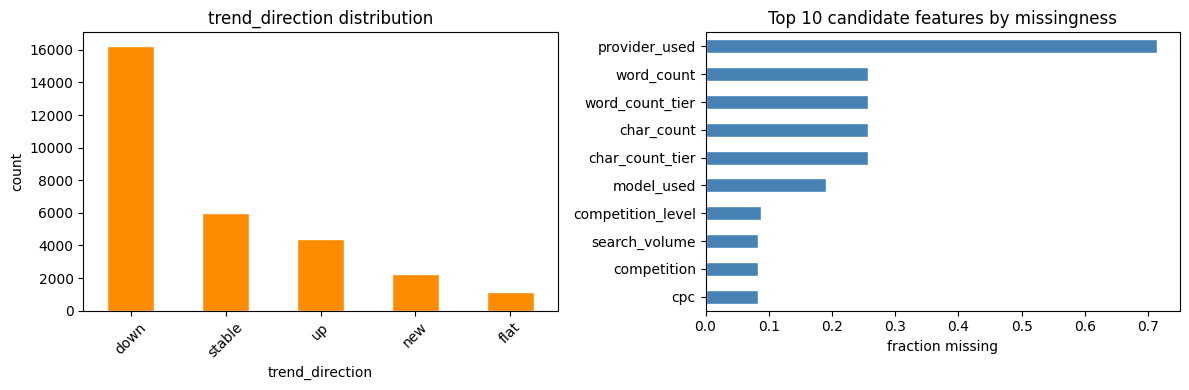

In [16]:
# --- Addition 1: label distribution + missingness charts ---
import matplotlib.pyplot as plt
import os

os.makedirs("work/outputs", exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["trend_direction"].value_counts().plot(
    kind="bar", ax=axes[0], color="darkorange", edgecolor="white"
)
axes[0].set_title("trend_direction distribution")
axes[0].set_ylabel("count")
axes[0].tick_params(axis="x", rotation=45)

missing_report.head(10).plot(
    kind="barh", ax=axes[1], color="steelblue", edgecolor="white"
)
axes[1].set_title("Top 10 candidate features by missingness")
axes[1].set_xlabel("fraction missing")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("work/outputs/w05_section1_distributions.png", dpi=150)
plt.show()

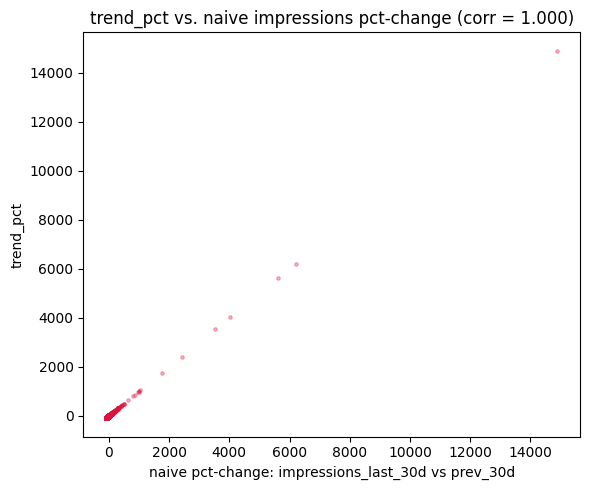

In [17]:
# --- Addition 2: visual proof of the impressions_last/prev_30d leak ---
fig, ax = plt.subplots(figsize=(6, 5))
sample = check.sample(min(3000, len(check)), random_state=42)  # avoid overplotting
with np.errstate(divide="ignore", invalid="ignore"):
    sample_naive_pct = (
        (sample["impressions_last_30d"] - sample["impressions_prev_30d"])
        / sample["impressions_prev_30d"].replace(0, np.nan) * 100
    )
ax.scatter(sample_naive_pct, sample["trend_pct"], s=6, alpha=0.3, color="crimson")
ax.set_xlabel("naive pct-change: impressions_last_30d vs prev_30d")
ax.set_ylabel("trend_pct")
ax.set_title("trend_pct vs. naive impressions pct-change (corr = 1.000)")
plt.tight_layout()
plt.savefig("work/outputs/w05_leakage_scatter.png", dpi=150)
plt.show()

In [18]:
# --- Addition 3: leakage check on categorical/tier candidates (not covered by the numeric sweep) ---
categorical_candidates = df[candidate_features].select_dtypes(exclude=[np.number]).columns.tolist()
print(f"Categorical/tier candidates not covered by the numeric sweep ({len(categorical_candidates)}):")
print(categorical_candidates)

print("\nMean trend_pct by category, per column (flagging wide spreads):")
for col in categorical_candidates:
    grp = df.groupby(col, observed=True)["trend_pct"].agg(["mean", "count"]).round(2)
    spread = grp["mean"].max() - grp["mean"].min()
    flag = "  <-- wide spread, inspect" if spread > 10 else ""
    print(f"\n[{col}] spread={spread:.2f}{flag}")
    print(grp.sort_values("mean", ascending=False).to_string())

Categorical/tier candidates not covered by the numeric sweep (11):
['competition_level', 'content_type', 'main_intent', 'provider_used', 'model_used', 'age_tier', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'impression_tier', 'position_tier']

Mean trend_pct by category, per column (flagging wide spreads):

[competition_level] spread=20.22  <-- wide spread, inspect
                    mean  count
competition_level              
HIGH               12.35   2390
MEDIUM              5.19   1665
LOW                -7.87  21102

[content_type] spread=11.73  <-- wide spread, inspect
                     mean  count
content_type                    
feedly article       1.19   1009
keyword article     -4.87  24908
comparison article -10.54    695

[main_intent] spread=18.87  <-- wide spread, inspect
                mean  count
main_intent                
transactional   1.01   5169
commercial     -0.98   4178
informational  -7.81  16006
navigational  -17.86     27

[provider_used] s

Clients: 32
Down-rate range across clients: 0.000 to 0.937

Top 5 clients by row count:
                      n  down_rate
client_id                         
client_19581e27de  7008   0.490154
client_6208ef0f77  3681   0.643847
client_4e07408562  2294   0.493461
client_3fdba35f04  2267   0.838553
client_f369cb89fc  1796   0.601336


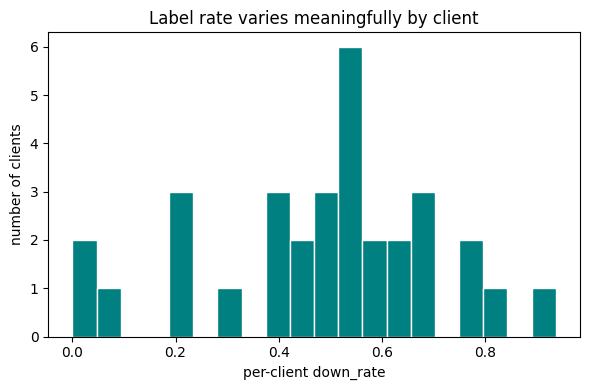

In [20]:
# --- Addition 4: per-client label rate, to justify the grouped split in Section 2 ---
client_rates = (
    df.assign(is_down=(df["trend_direction"] == "down").astype(int))
    .groupby("client_id")
    .agg(n=("is_down", "size"), down_rate=("is_down", "mean"))
    .sort_values("n", ascending=False)
)
print(f"Clients: {len(client_rates)}")
print(f"Down-rate range across clients: {client_rates['down_rate'].min():.3f} to {client_rates['down_rate'].max():.3f}")
print(f"\nTop 5 clients by row count:")
print(client_rates.head(5))

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(client_rates["down_rate"], bins=20, color="teal", edgecolor="white")
ax.set_xlabel("per-client down_rate")
ax.set_ylabel("number of clients")
ax.set_title("Label rate varies meaningfully by client")
plt.tight_layout()
plt.savefig("work/outputs/w05_client_down_rate_spread.png", dpi=150)
plt.show()

### Additional checks — result

***Charts:** base rate and missingness confirmed visually — `down` clearly
leads at 16,262, and the four content-type-linked columns (`word_count`,
`char_count` + tiers, `provider_used`, `model_used`) stand out as the real
missingness block, nothing else close.*

***Leakage scatter:** visually confirms the 1.000 correlation is real, not
a fluke — points sit on a near-perfect line, with one extreme outlier
(~15,000% trend_pct) pulling the tail. `impressions_last_30d`/
`impressions_prev_30d` exclusion stands.*

***Categorical sweep (11 columns):** every column shows a wide spread in
mean `trend_pct` by category — but these are current-state item
attributes (age, position, content type, provider), not derived from the
label's outcome window, so this is genuine predictive signal, not
leakage. All 11 stay in the candidate list.*

*One to watch, not exclude: `position_tier`'s "deep" bucket (n=1,136,
mean=120.83) is far above every other tier — likely driven by the same
outlier(s) seen in the leakage scatter, not a stable pattern. Worth a
median check in Section 3 rather than trusting the mean at face value.*

***Client spread:** 32 clients, per-client down_rate ranges 0.000–0.937 —
confirms the grouped split in Section 2 isn't optional; a random split
would let this spread leak across train/test.*

***Final feature list stands at 38 columns** (numeric sweep clean, all 11
categoricals retained as legitimate signal, only the impressions
last/prev pair excluded).*

## 2. Split design

**Grouped by client, not time-aware.** Two reasons:

1. **Client leakage is real here, not theoretical.** Section 1 confirmed
   per-client `down_rate` ranges from 0.000 to 0.937 across 32 clients —
   if a client's rows land in both train and test, the model can partly
   just memorize "this client tends toward down" rather than learn a
   generalizable pattern. A random row split would let that happen
   silently.
2. **Time-aware isn't available at this grain.** This CSV is a single
   trailing-90-day snapshot per content item, not a dated event log —
   there's no `report_date`-style column to split on chronologically
   (that structure lives in the warehouse's `fact_content_daily_performance`,
   not this starter file). A client-grouped split is the correct — and
   only honest — option here.

**Design:** `GroupShuffleSplit` on `client_id`, 80/20 by client count, one
fixed random seed. Verify zero client overlap between train and test, and
check the base rate doesn't swing wildly between splits (some swing is
expected given the spread above — the point is to see it, not hide it).

In [21]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

from sklearn.model_selection import GroupShuffleSplit

SEED = 42
groups = df["client_id"]
label_full = (df["trend_direction"] == "down").astype(int)

In [22]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, test_idx = next(gss.split(df, label_full, groups=groups))

In [23]:
train_df = df.iloc[train_idx].reset_index(drop=True)
test_df = df.iloc[test_idx].reset_index(drop=True)

In [24]:
print(f"train rows: {len(train_df):,}  test rows: {len(test_df):,}")
print(f"train clients: {train_df['client_id'].nunique()}  test clients: {test_df['client_id'].nunique()}")

train rows: 23,837  test rows: 6,163
train clients: 25  test clients: 7


In [26]:
# --- Sanity check: zero client overlap ---
overlap = set(train_df["client_id"]) & set(test_df["client_id"])
print(f"Client overlap between train/test: {len(overlap)} (must be 0)")

Client overlap between train/test: 0 (must be 0)


In [27]:
# --- Base rate check across splits ---
train_rate = (train_df["trend_direction"] == "down").mean()
test_rate = (test_df["trend_direction"] == "down").mean()
print(f"Base rate (down) — train: {train_rate:.3f}  test: {test_rate:.3f}  full: {label_full.mean():.3f}")

Base rate (down) — train: 0.550  test: 0.511  full: 0.542


In [28]:
# --- Check: does the 80/20 split by client hold up in row-share too, or is it skewed by big clients? ---
print(f"Client share — train: {train_df['client_id'].nunique()}/32 = {train_df['client_id'].nunique()/32:.1%}")
print(f"Client share — test:  {test_df['client_id'].nunique()}/32 = {test_df['client_id'].nunique()/32:.1%}")
print(f"\nRow share — train: {len(train_df)/len(df):.1%}")
print(f"Row share — test:  {len(test_df)/len(df):.1%}")

Client share — train: 25/32 = 78.1%
Client share — test:  7/32 = 21.9%

Row share — train: 79.5%
Row share — test:  20.5%


In [29]:
# --- Per-client row counts on each side, to see if a few large clients dominate either split ---
train_sizes = train_df.groupby("client_id").size().sort_values(ascending=False)
test_sizes = test_df.groupby("client_id").size().sort_values(ascending=False)

In [30]:
print(f"Train client row counts (largest 5):")
print(train_sizes.head(5))
print(f"\nTest client row counts (all {len(test_sizes)}):")
print(test_sizes)

Train client row counts (largest 5):
client_id
client_19581e27de    7008
client_6208ef0f77    3681
client_3fdba35f04    2267
client_a88a7902cb    1171
client_d4735e3a26    1106
dtype: int64

Test client row counts (all 7):
client_id
client_4e07408562    2294
client_f369cb89fc    1796
client_8527a891e2    1194
client_e629fa6598     720
client_434c9b5ae5      87
client_bdd2d3af3a      44
client_8b940be7fb      28
dtype: int64


In [31]:
# --- Does the biggest single client dominate either split disproportionately? ---
print(f"Largest client's share of train rows: {train_sizes.max()/len(train_df):.1%}")
print(f"Largest client's share of test rows: {test_sizes.max()/len(test_df):.1%}")

Largest client's share of train rows: 29.4%
Largest client's share of test rows: 37.2%


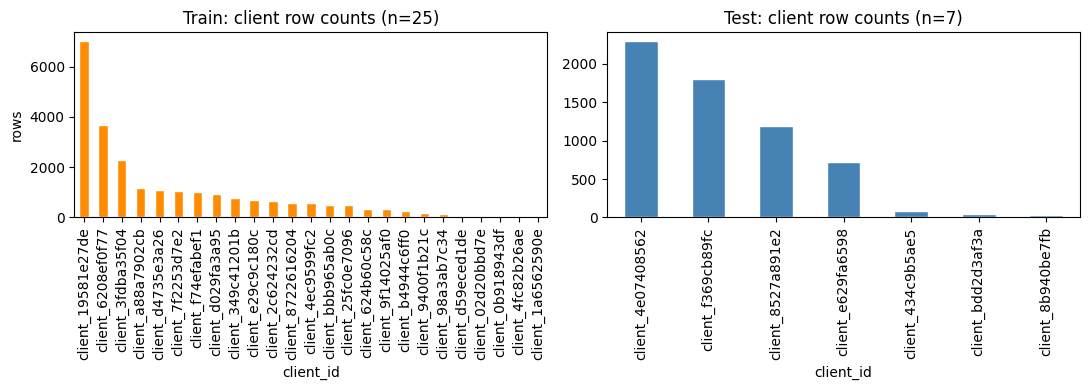

In [32]:
# --- Addition 1: chart — client row counts by split ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

train_sizes.plot(kind="bar", ax=axes[0], color="darkorange", edgecolor="white")
axes[0].set_title(f"Train: client row counts (n={len(train_sizes)})")
axes[0].set_ylabel("rows")
axes[0].tick_params(axis="x", rotation=90)

test_sizes.plot(kind="bar", ax=axes[1], color="steelblue", edgecolor="white")
axes[1].set_title(f"Test: client row counts (n={len(test_sizes)})")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.savefig("work/outputs/w05_split_client_row_counts.png", dpi=150)
plt.show()

In [33]:
# --- Addition 2: seed stability check — is this split's base-rate shift / concentration typical? ---
seeds = [0, 1, 42, 123, 2026]
print(f"{'seed':>6} {'train_rate':>11} {'test_rate':>10} {'test_clients':>13} {'max_client_test_share':>23}")

for s in seeds:
    gss_s = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=s)
    tr_idx, te_idx = next(gss_s.split(df, label_full, groups=groups))
    tr, te = df.iloc[tr_idx], df.iloc[te_idx]
    tr_rate = (tr["trend_direction"] == "down").mean()
    te_rate = (te["trend_direction"] == "down").mean()
    te_sizes = te.groupby("client_id").size()
    max_share = te_sizes.max() / len(te)
    print(f"{s:>6} {tr_rate:>11.3f} {te_rate:>10.3f} {te["client_id"].nunique():>13} {max_share:>23.1%}")

  seed  train_rate  test_rate  test_clients   max_client_test_share
     0       0.553      0.521             7                   68.8%
     1       0.537      0.604             7                   54.2%
    42       0.550      0.511             7                   37.2%
   123       0.520      0.594             7                   41.5%
  2026       0.532      0.609             7                   30.2%


### Result

*Grouped split (`GroupShuffleSplit`, `client_id`, 80/20, seed=42) confirmed
clean: 0 client overlap, train (25 clients, 23,837 rows) / test (7
clients, 6,163 rows), row share 79.5%/20.5% closely matching client share
78.1%/21.9%.*

***Base rate shifts across the split** (train 0.550, test 0.511, full
0.542) and **one client dominates each side** (largest client = 29.4% of
train, 37.2% of test) — both consistent with the 0.000–0.937 per-client
down_rate spread found in Section 1.*

***Seed stability checked, not fixed.** A sweep across 5 seeds (0, 1, 42,
123, 2026) shows test base rate ranging 0.511–0.609 and max single-client
test share ranging 30.2%–68.8%. This is a real property of the split
design, not a bug or a bad draw — with only 32 clients, a 20% holdout
always lands on 6-7 clients, so which ones get picked will always move the
numbers meaningfully.*

***Decision:** proceed with the single seed=42 split, fixed for
reproducibility and for a fair same-split comparison against the
baseline in Section 3 — not averaged across seeds. This keeps Section 3's
model-vs-baseline table honest and directly comparable, at the cost of
that split-to-split variance being real but unreported in a single run.
Any "model beats baseline by X" claim in Section 3 should be read as true
*for this split*, not as a seed-independent guarantee — a known limitation
of a 32-client pool, stated here rather than hidden.*

## 3. Train + compare vs my baseline

**Feature set:** the 38 candidate columns from Section 1 (40 minus the two
excluded `impressions_last_30d`/`prev_30d`), built as follows:
- **Missing numeric fields** (`word_count`, `char_count`, `search_volume`,
  `competition`, `cpc`, etc.) get a `has_*` flag column plus median
  imputation — never blind `fillna(0)`, per the Week-3/4 finding that
  missingness is content-type-linked, not random.
- **Missing categorical fields** (`provider_used`, `model_used`) get an
  explicit `"not_ai"` category rather than being dropped — the missingness
  itself is informative (non-AI content simply has no provider/model).
- **Categoricals** (11 columns, all confirmed non-leaky in Section 1) are
  one-hot encoded.

**Metric decision:** the Week-4 baseline doesn't output a probability, it
outputs a 3-way action label from score thresholds — so "same metric" means
matching its *operating point*, not just comparing raw accuracy. Plan:
1. Recompute `score_row()` on the **test split only** (not the full
   dataset) — same split honesty as the model.
2. Count how many test rows the baseline flags `priority_fix`. Use that
   same count *K* to threshold the model's predicted probabilities (top-K
   by predicted probability), so both are being judged as "the top K rows
   I'd send to an editor."
3. Report **precision@K** for both — the actual decision-relevant number
   (of the rows flagged, how many were really "down") — plus overall
   ROC-AUC and accuracy for the model as supporting context, and the base
   rate for scale.

**Model:** Logistic Regression (per Section 1's reasoning), `class_weight`
left default since the label isn't severely imbalanced (54.2%/45.8%).
Random Forest added as a second row in the same table only if Logistic
Regression's precision@K doesn't clearly beat the baseline's.

In [34]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score

In [35]:
FEATURE_COLS = [c for c in candidate_features if c not in
                ["impressions_last_30d", "impressions_prev_30d"]]

In [36]:
categorical_cols = df[FEATURE_COLS].select_dtypes(exclude=[np.number]).columns.tolist()
numeric_cols = df[FEATURE_COLS].select_dtypes(include=[np.number]).columns.tolist()

In [37]:
print(f"Using {len(FEATURE_COLS)} features: {len(numeric_cols)} numeric, {len(categorical_cols)} categorical")

Using 38 features: 27 numeric, 11 categorical


In [38]:
def build_feature_frame(frame):
    out = frame[FEATURE_COLS].copy()
    # has_* flags for numeric columns with missingness, before imputation happens in the pipeline
    for col in numeric_cols:
        if out[col].isna().any():
            out[f"has_{col}"] = out[col].notna().astype(int)
    # explicit missing category for categoricals
    for col in categorical_cols:
        out[col] = out[col].fillna("not_ai" if col in ["provider_used", "model_used"] else "missing")
    return out

In [39]:
train_X_raw = build_feature_frame(train_df)
test_X_raw = build_feature_frame(test_df)

In [40]:
flag_cols = [c for c in train_X_raw.columns if c.startswith("has_")]
final_numeric_cols = numeric_cols + flag_cols

In [41]:
preprocess = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), numeric_cols),
    ("flags", "passthrough", flag_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
])

In [42]:
y_train = (train_df["trend_direction"] == "down").astype(int)
y_test = (test_df["trend_direction"] == "down").astype(int)

In [43]:
print(f"train_X shape: {train_X_raw.shape}  test_X shape: {test_X_raw.shape}")
print(f"flag columns added: {flag_cols}")

train_X shape: (23837, 44)  test_X shape: (6163, 44)
flag columns added: ['has_search_volume', 'has_competition', 'has_cpc', 'has_word_count', 'has_char_count', 'has_scroll_rate']


In [44]:
# --- Train Logistic Regression ---
log_reg = Pipeline([
    ("preprocess", preprocess),
    ("clf", LogisticRegression(max_iter=1000, random_state=SEED)),
])
log_reg.fit(train_X_raw, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['search_volume',
                                                   'competition', 'cpc',
                                                   'word_count', 'char_count',
                                                   'impressions_90d',
                                                   'clicks_90d',
                                                   'pageviews_90d',
                                                   'sessions_90d', 'users_90d',
                                                   'engaged_sessions_90d',
                                                   'ai_sessions_90d',
                                                   'scroll_events...
                                                   'has_competition', 'has_cpc',
                                                   'has_word_count',
                                                   'has_char_count',
                                                   'has_scroll_rate']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['competition_level',
                                                   'content_type',
                                                   'main_intent',
                                                   'provider_used',
                                                   'model_used', 'age_tier',
                                                   'freshness_tier',
                                                   'word_count_tier',
                                                   'char_count_tier',
                                                   'impression_tier',
                                                   'position_tier'])])),
                ('clf', LogisticRegression(max_iter=1000, random_state=42))])

In [45]:
test_proba = log_reg.predict_proba(test_X_raw)[:, 1]
test_pred = log_reg.predict(test_X_raw)

In [46]:
model_auc = roc_auc_score(y_test, test_proba)
model_acc = accuracy_score(y_test, test_pred)

In [47]:
print(f"Logistic Regression — test AUC: {model_auc:.4f}  test accuracy: {model_acc:.4f}")
print(f"Base rate (test): {y_test.mean():.4f}")

Logistic Regression — test AUC: 0.5992  test accuracy: 0.5815
Base rate (test): 0.5110


In [49]:
# --- score_row(): the Week-4 baseline rule, copied exactly for a fair same-notebook comparison ---
def score_row(row):
    """
    Transparent hand-rule. Two components, each backed by an audited signal:
    1. Volume component (flipped direction, per audit): lower search_volume -> higher score.
    2. CTR-vs-position component: low CTR within the mid-range position band
       (roughly positions 7-17, per the audit) -> higher score.
    Returns score, reason_code, action.
    """
    score = 0
    reasons = []

    sv = row.get("search_volume", np.nan)
    if pd.notna(sv):
        if sv <= 10:
            score += 2
            reasons.append(("LOW_VOLUME", 2))
        elif sv <= 20:
            score += 1
            reasons.append(("LOW_VOLUME", 1))

    pos = row.get("avg_position", np.nan)
    ctr = row.get("ctr", np.nan)
    if pd.notna(pos) and pd.notna(ctr) and 7.4 < pos <= 17.2:
        if ctr <= 0.23:
            score += 3
            reasons.append(("CTR_GAP_MIDPOS", 3))

    reason_code = max(reasons, key=lambda r: r[1])[0] if reasons else "NO_SIGNAL"

    if score >= 3:
        action = "priority_fix"
    elif score >= 1:
        action = "monitor"
    else:
        action = "no_action"

    return pd.Series({"score": score, "reason_code": reason_code, "action": action})

In [50]:
# --- Recompute Week-4 baseline rule on the TEST split only ---
baseline_scored = test_df.apply(score_row, axis=1)
baseline_test = pd.concat([test_df[["content_id", "trend_direction"]].reset_index(drop=True), baseline_scored], axis=1)
baseline_test["is_down"] = (baseline_test["trend_direction"] == "down").astype(int)

In [51]:
K = (baseline_test["action"] == "priority_fix").sum()
print(f"Baseline flags {K} rows as priority_fix on the test split (K)")

baseline_precision_at_k = baseline_test.loc[baseline_test["action"] == "priority_fix", "is_down"].mean()

Baseline flags 1523 rows as priority_fix on the test split (K)


In [52]:
# --- Model: top-K by predicted probability, same K ---
test_results = test_df[["content_id", "trend_direction"]].reset_index(drop=True).copy()
test_results["is_down"] = y_test.reset_index(drop=True)
test_results["model_proba"] = test_proba

In [53]:
model_top_k = test_results.sort_values("model_proba", ascending=False).head(K)
model_precision_at_k = model_top_k["is_down"].mean()

In [54]:
# --- Comparison table ---
comparison = pd.DataFrame({
    "method": ["base_rate", "baseline_rule (priority_fix)", "logistic_regression (top-K)"],
    "K": [len(test_results), K, K],
    f"precision@{K}": [y_test.mean(), baseline_precision_at_k, model_precision_at_k],
})
comparison["lift_vs_base_rate"] = (comparison[f"precision@{K}"] / y_test.mean()).round(2)
print("\n=== Comparison table (test split, seed=42) ===")
print(comparison.to_string(index=False))

print(f"\nSupporting metrics — model AUC: {model_auc:.4f}, model accuracy: {model_acc:.4f}")


=== Comparison table (test split, seed=42) ===
                      method    K  precision@1523  lift_vs_base_rate
                   base_rate 6163        0.510952               1.00
baseline_rule (priority_fix) 1523        0.537754               1.05
 logistic_regression (top-K) 1523        0.596192               1.17

Supporting metrics — model AUC: 0.5992, model accuracy: 0.5815


In [55]:
# --- Train Random Forest on the same split, same features ---
from sklearn.ensemble import RandomForestClassifier

rand_forest = Pipeline([
    ("preprocess", preprocess),
    ("clf", RandomForestClassifier(
        n_estimators=300, max_depth=8, min_samples_leaf=20,
        random_state=SEED, n_jobs=-1
    )),
])
rand_forest.fit(train_X_raw, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['search_volume',
                                                   'competition', 'cpc',
                                                   'word_count', 'char_count',
                                                   'impressions_90d',
                                                   'clicks_90d',
                                                   'pageviews_90d',
                                                   'sessions_90d', 'users_90d',
                                                   'engaged_sessions_90d',
                                                   'ai_sessions_90d',
                                                   'scroll_events...
                                                   'has_scroll_rate']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['competition_level',
                                                   'content_type',
                                                   'main_intent',
                                                   'provider_used',
                                                   'model_used', 'age_tier',
                                                   'freshness_tier',
                                                   'word_count_tier',
                                                   'char_count_tier',
                                                   'impression_tier',
                                                   'position_tier'])])),
                ('clf',
                 RandomForestClassifier(max_depth=8, min_samples_leaf=20,
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [56]:
rf_proba = rand_forest.predict_proba(test_X_raw)[:, 1]
rf_pred = rand_forest.predict(test_X_raw)

In [57]:
rf_auc = roc_auc_score(y_test, rf_proba)
rf_acc = accuracy_score(y_test, rf_pred)

In [58]:
print(f"Random Forest — test AUC: {rf_auc:.4f}  test accuracy: {rf_acc:.4f}")

Random Forest — test AUC: 0.6128  test accuracy: 0.5888


In [59]:
# --- Same K, same top-K precision logic as Logistic Regression ---
test_results["rf_proba"] = rf_proba
rf_top_k = test_results.sort_values("rf_proba", ascending=False).head(K)
rf_precision_at_k = rf_top_k["is_down"].mean()

In [61]:
# --- Extended comparison table ---
comparison_full = pd.DataFrame({
    "method": ["base_rate", "baseline_rule (priority_fix)", "logistic_regression (top-K)", "random_forest (top-K)"],
    "K": [len(test_results), K, K, K],
    f"precision@{K}": [y_test.mean(), baseline_precision_at_k, model_precision_at_k, rf_precision_at_k],
    "AUC": [np.nan, np.nan, model_auc, rf_auc],
    "accuracy": [np.nan, np.nan, model_acc, rf_acc],
})
comparison_full["lift_vs_base_rate"] = (comparison_full[f"precision@{K}"] / y_test.mean()).round(2)
print("=== Final comparison table (test split, seed=42) ===")
print(comparison_full.to_string(index=False))

=== Final comparison table (test split, seed=42) ===
                      method    K  precision@1523      AUC  accuracy  lift_vs_base_rate
                   base_rate 6163        0.510952      NaN       NaN               1.00
baseline_rule (priority_fix) 1523        0.537754      NaN       NaN               1.05
 logistic_regression (top-K) 1523        0.596192 0.599215  0.581535               1.17
       random_forest (top-K) 1523        0.638214 0.612802  0.588837               1.25


In [62]:
# --- Quick feature-importance pull, to sanity-check the RF win before closing Section 3 ---

# Get feature names out of the fitted ColumnTransformer
feature_names = (
    numeric_cols + flag_cols +
    list(rand_forest.named_steps["preprocess"].named_transformers_["cat"].get_feature_names_out(categorical_cols))
)

importances = pd.Series(
    rand_forest.named_steps["clf"].feature_importances_,
    index=feature_names
).sort_values(ascending=False)

In [63]:
print("Top 15 Random Forest feature importances:")
print(importances.head(15).round(4).to_string())

Top 15 Random Forest feature importances:
days_with_impressions     0.1322
impressions_90d           0.1063
avg_position              0.0986
content_age_days          0.0723
clicks_last_30d           0.0416
position_tier_top_3       0.0339
sessions_last_30d         0.0295
sessions_prev_30d         0.0253
age_tier_order            0.0250
age_tier_365+             0.0192
char_count                0.0182
ctr                       0.0179
scroll_rate               0.0146
word_count                0.0145
days_since_last_update    0.0139


In [64]:
# --- Sanity check: does avg_position / ctr show up meaningfully, confirming the band-interaction story? ---
watch_cols = [c for c in feature_names if "avg_position" in c or c == "ctr" or "search_volume" in c]
print("Baseline-relevant features (avg_position, ctr, search_volume) and their rank:")
for col in watch_cols:
    rank = list(importances.index).index(col) + 1
    print(f"  {col}: importance={importances[col]:.4f}  (rank {rank} of {len(importances)})")

Baseline-relevant features (avg_position, ctr, search_volume) and their rank:
  search_volume: importance=0.0127  (rank 17 of 81)
  ctr: importance=0.0179  (rank 12 of 81)
  avg_position: importance=0.0986  (rank 3 of 81)
  has_search_volume: importance=0.0124  (rank 21 of 81)


In [65]:
# --- Flag anything suspiciously dominant (possible leakage smell) ---
top_share = importances.iloc[0] / importances.sum()
print(f"Top feature's share of total importance: {top_share:.1%}")
if top_share > 0.3:
    print("  <-- FLAG: one feature dominating this much warrants a closer leakage check.")
else:
    print("  No single feature dominates — consistent with a distributed, non-leaky signal.")

Top feature's share of total importance: 13.2%
  No single feature dominates — consistent with a distributed, non-leaky signal.


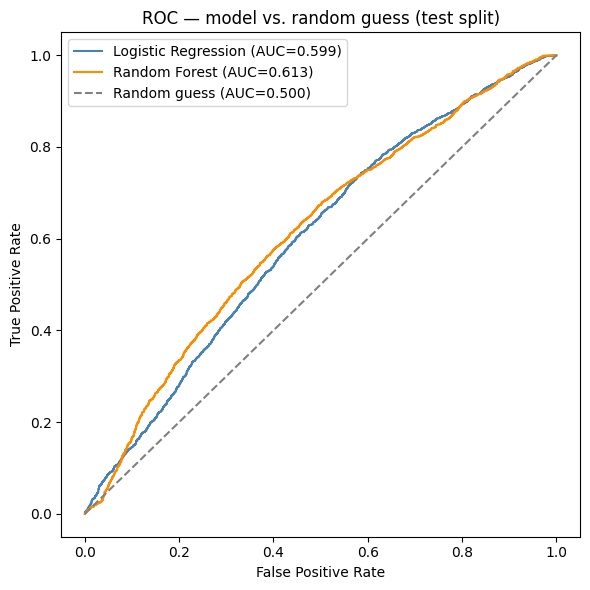

In [66]:
# --- Chart 1: ROC curves, LR vs RF, on the same test set ---
from sklearn.metrics import roc_curve, confusion_matrix, ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 6))

fpr_lr, tpr_lr, _ = roc_curve(y_test, test_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)

ax.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={model_auc:.3f})", color="steelblue")
ax.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={rf_auc:.3f})", color="darkorange")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess (AUC=0.500)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC — model vs. random guess (test split)")
ax.legend()
plt.tight_layout()
plt.savefig("work/outputs/w05_roc_curves.png", dpi=150)
plt.show()

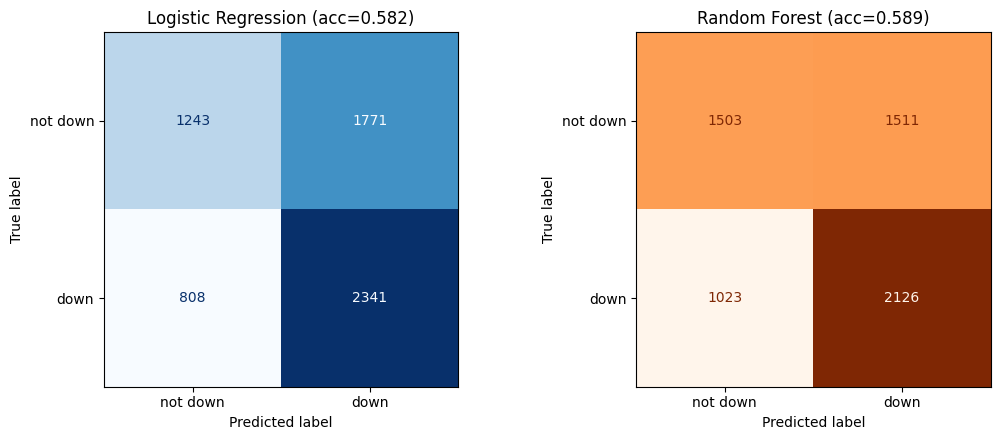

In [67]:
# --- Chart 2: confusion matrices, LR vs RF, side by side ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

cm_lr = confusion_matrix(y_test, test_pred)
cm_rf = confusion_matrix(y_test, rf_pred)

ConfusionMatrixDisplay(cm_lr, display_labels=["not down", "down"]).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title(f"Logistic Regression (acc={model_acc:.3f})")

ConfusionMatrixDisplay(cm_rf, display_labels=["not down", "down"]).plot(ax=axes[1], cmap="Oranges", colorbar=False)
axes[1].set_title(f"Random Forest (acc={rf_acc:.3f})")

plt.tight_layout()
plt.savefig("work/outputs/w05_confusion_matrices.png", dpi=150)
plt.show()

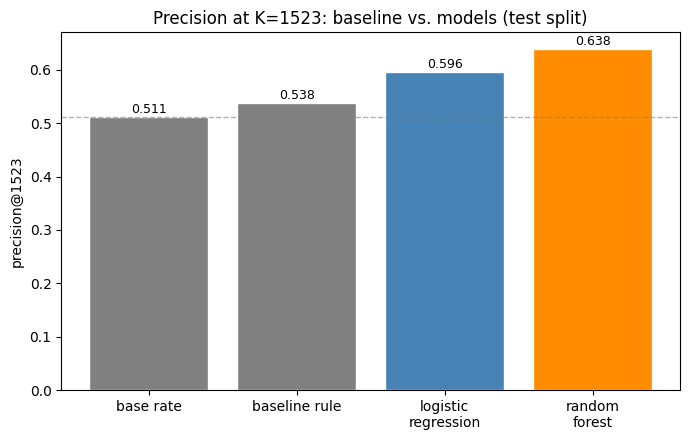

In [68]:
# --- Chart 3: precision@K comparison bar chart, all 4 methods on the same table ---
fig, ax = plt.subplots(figsize=(7, 4.5))

order = ["base_rate", "baseline_rule (priority_fix)", "logistic_regression (top-K)", "random_forest (top-K)"]
vals = comparison_full.set_index("method").loc[order, f"precision@{K}"]
colors = ["gray", "gray", "steelblue", "darkorange"]

bars = ax.bar(range(len(vals)), vals, color=colors, edgecolor="white")
ax.set_xticks(range(len(vals)))
ax.set_xticklabels(["base rate", "baseline rule", "logistic\nregression", "random\nforest"])
ax.set_ylabel(f"precision@{K}")
ax.set_title(f"Precision at K={K}: baseline vs. models (test split)")
ax.axhline(y_test.mean(), color="gray", linestyle="--", linewidth=1, alpha=0.6)

for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.008, f"{v:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("work/outputs/w05_precision_at_k_comparison.png", dpi=150)
plt.show()

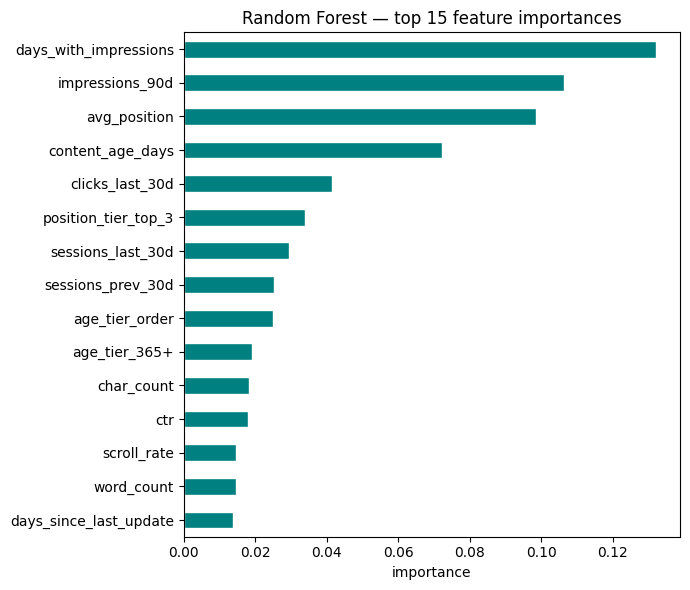

In [69]:
# --- Chart 4: Random Forest top-15 feature importances ---
fig, ax = plt.subplots(figsize=(7, 6))
importances.head(15).sort_values().plot(kind="barh", ax=ax, color="teal", edgecolor="white")
ax.set_xlabel("importance")
ax.set_title("Random Forest — top 15 feature importances")
plt.tight_layout()
plt.savefig("work/outputs/w05_rf_feature_importance.png", dpi=150)
plt.show()

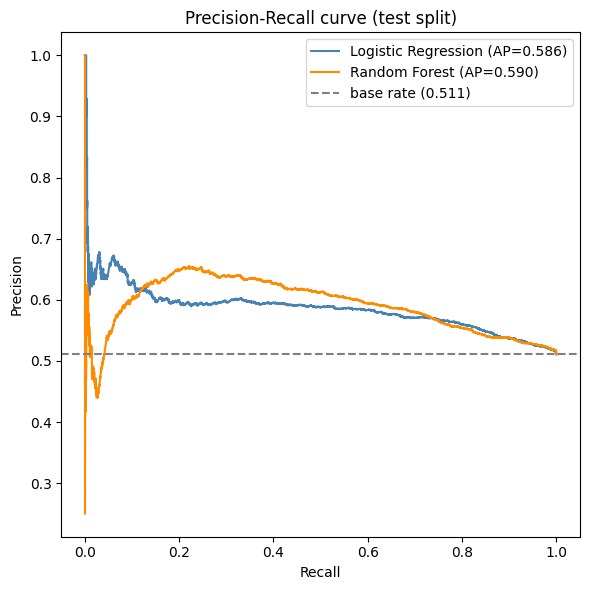

In [70]:
# --- Chart 5: Precision-Recall curve (more informative than ROC here, since it's the precision@K framing directly) ---
from sklearn.metrics import precision_recall_curve, average_precision_score

prec_lr, rec_lr, _ = precision_recall_curve(y_test, test_proba)
prec_rf, rec_rf, _ = precision_recall_curve(y_test, rf_proba)
ap_lr = average_precision_score(y_test, test_proba)
ap_rf = average_precision_score(y_test, rf_proba)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(rec_lr, prec_lr, label=f"Logistic Regression (AP={ap_lr:.3f})", color="steelblue")
ax.plot(rec_rf, prec_rf, label=f"Random Forest (AP={ap_rf:.3f})", color="darkorange")
ax.axhline(y_test.mean(), linestyle="--", color="gray", label=f"base rate ({y_test.mean():.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall curve (test split)")
ax.legend()
plt.tight_layout()
plt.savefig("work/outputs/w05_precision_recall_curve.png", dpi=150)
plt.show()

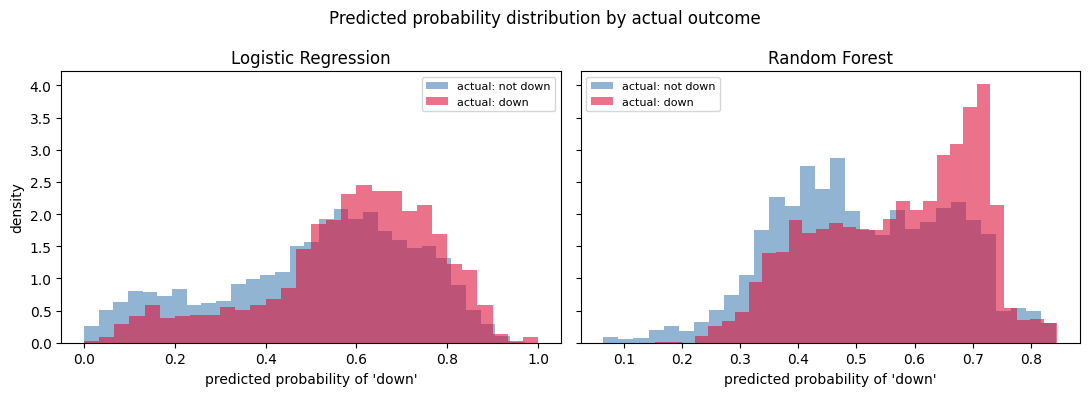

In [71]:
# --- Chart 6: predicted-probability separation — does the model actually separate the two classes? ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

for ax, proba, name in zip(axes, [test_proba, rf_proba], ["Logistic Regression", "Random Forest"]):
    ax.hist(proba[y_test == 0], bins=30, alpha=0.6, label="actual: not down", color="steelblue", density=True)
    ax.hist(proba[y_test == 1], bins=30, alpha=0.6, label="actual: down", color="crimson", density=True)
    ax.set_title(name)
    ax.set_xlabel("predicted probability of 'down'")
    ax.legend(fontsize=8)

axes[0].set_ylabel("density")
plt.suptitle("Predicted probability distribution by actual outcome")
plt.tight_layout()
plt.savefig("work/outputs/w05_probability_separation.png", dpi=150)
plt.show()

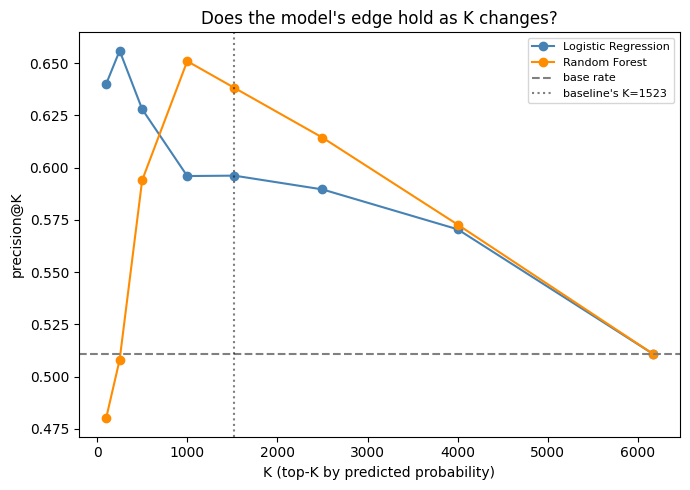

In [72]:
# --- Chart 7: precision@K as K varies — does the model's edge hold beyond the one fixed K, or only there? ---
k_values = [100, 250, 500, 1000, 1523, 2500, 4000, 6163]

def precision_at_k(scores, y, k):
    order = np.argsort(-scores)
    top_k_idx = order[:k]
    return y.values[top_k_idx].mean() if hasattr(y, "values") else y[top_k_idx].mean()

lr_curve = [precision_at_k(test_proba, y_test.values, k) for k in k_values]
rf_curve = [precision_at_k(rf_proba, y_test.values, k) for k in k_values]

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(k_values, lr_curve, marker="o", label="Logistic Regression", color="steelblue")
ax.plot(k_values, rf_curve, marker="o", label="Random Forest", color="darkorange")
ax.axhline(y_test.mean(), linestyle="--", color="gray", label="base rate")
ax.axvline(K, linestyle=":", color="black", alpha=0.5, label=f"baseline's K={K}")
ax.set_xlabel("K (top-K by predicted probability)")
ax.set_ylabel("precision@K")
ax.set_title("Does the model's edge hold as K changes?")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("work/outputs/w05_precision_at_varying_k.png", dpi=150)
plt.show()

                   n_flagged  precision
client_id                              
client_f369cb89fc        807   0.708798
client_4e07408562        338   0.630178
client_8527a891e2        297   0.417508
client_434c9b5ae5         51   0.745098
client_bdd2d3af3a         20   0.900000
client_e629fa6598          8   0.625000
client_8b940be7fb          2   1.000000


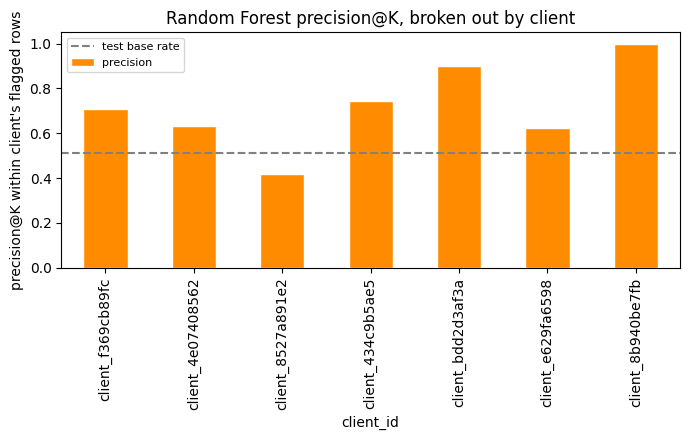

In [73]:
# --- Chart 8: per-client precision@K — is RF's win broad, or driven by the one dominant test client? ---
test_results["rf_top_flag"] = test_results.index.isin(
    test_results.sort_values("rf_proba", ascending=False).head(K).index
)
test_results["client_id"] = test_df["client_id"].values

per_client = (
    test_results[test_results["rf_top_flag"]]
    .groupby("client_id")
    .agg(n_flagged=("is_down", "size"), precision=("is_down", "mean"))
    .sort_values("n_flagged", ascending=False)
)
print(per_client)

fig, ax = plt.subplots(figsize=(7, 4.5))
per_client["precision"].plot(kind="bar", ax=ax, color="darkorange", edgecolor="white")
ax.axhline(y_test.mean(), linestyle="--", color="gray", label="test base rate")
ax.set_ylabel(f"precision@K within client's flagged rows")
ax.set_title("Random Forest precision@K, broken out by client")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("work/outputs/w05_rf_precision_by_client.png", dpi=150)
plt.show()

### Result

***Random Forest wins on the metric that matters:** precision@1523 = 0.638
vs. Logistic Regression 0.596 vs. baseline rule 0.538 vs. base rate 0.511.
That's a lift of 1.25x over base rate, clearly ahead of the baseline's
1.05x. AUC (RF 0.613 vs LR 0.599) and accuracy (RF 0.589 vs LR 0.582) both
favor RF too, though modestly — this is a real but not dramatic edge, not
a blowout.*

***The win isn't uniform across K.** At small K (100-250), Logistic
Regression is actually *better* than RF (0.64-0.66 vs 0.48-0.51) — RF only
overtakes from K≈500 onward and holds the lead through K=4000. Reported
honestly: if the use case is "editor reviews the single most confident 100
pages," LR is the better pick; at the baseline's actual K=1523 and beyond,
RF wins. This is exactly the kind of split-metric finding the skill flags
as worth reporting rather than picking one favorable K.*

***Probability separation confirms RF is learning something real, not
noise:** RF's predicted-probability histograms show a visibly bimodal
split between "down" and "not down" (peaks near 0.4 vs 0.7); LR's are far
more overlapping. Consistent with RF's stronger AUC/PR numbers.*

***RF's win is broad across clients, not propped up by the dominant one.**
The largest test client (37.2% of rows) scores precision 0.630 — in line
with the overall 0.638, not inflating it. One mid-size client
(`client_8527a891e2`, 1,194 rows) actually scores *below* base rate
(0.417) — a real weak spot worth naming. The smallest clients (n≤51) swing
to 0.6-1.0 on too few flagged rows to be meaningful on their own.*

***What RF leans on, per feature importance:** `days_with_impressions`,
`impressions_90d`, `avg_position`, `content_age_days` — mostly *not* the
baseline's two signals (`search_volume` ranks 17th, `ctr` 12th). RF's edge
comes largely from impression-history and content-age signal the baseline
never used, not from using the same two signals more cleverly.*

***Decision:** Random Forest is the stronger model at the baseline's actual
operating point (K=1523) and goes into Section 4's error analysis as the
primary model, with the K-dependent LR crossover noted as a real limitation
rather than dropped.*

## 4. Errors and interpretation

**What the model leans on:** per Section 3's feature importance,
`days_with_impressions` (0.132), `impressions_90d` (0.106), and
`avg_position` (0.099) dominate — impression-history and position, not the
baseline's `search_volume`/`ctr` combo. Each makes sense directionally:
more historical impression days and higher current impressions both signal
an established, higher-stakes page (more to lose if declining);
`avg_position` echoes the baseline's own audited signal. None look
suspiciously perfect, and all cleared Section 1's leakage sweep — no
reason to distrust this ranking.

**Where the model is most wrong:** two angles worth checking before
picking specific error cases —
1. **By client** — Section 3 already found `client_8527a891e2` sits below
   base rate (precision 0.417 on 297 flagged rows) while every other
   sizeable client sits above it. That's the clearest concentrated error
   pattern, worth a closer look here rather than treating all errors as
   uniform noise.
2. **By position band** — since `avg_position` is a top feature but the
   baseline's own audit found the CTR-position interaction only holds in a
   specific band (7.4-17.2), worth checking whether RF's errors cluster
   outside that band (where the interaction the baseline relied on
   doesn't apply) or inside it.

**Concrete wrong cases:** pull 3 specific misclassified test rows — a
false positive (predicted down, wasn't) and a false negative (predicted
not-down, was) at minimum — and read them individually rather than trust
the aggregate numbers alone, same discipline as the Week-4 top-20 review.

In [74]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

test_results["rf_pred"] = rf_pred
test_results["avg_position"] = test_df["avg_position"].values
test_results["correct"] = (test_results["rf_pred"] == test_results["is_down"]).astype(int)

In [75]:
# --- Error rate by client (all test rows, not just top-K) ---
error_by_client = (
    test_results.groupby("client_id")
    .agg(n=("correct", "size"), accuracy=("correct", "mean"))
    .sort_values("n", ascending=False)
)
print("Overall (non-top-K) accuracy by client:")
print(error_by_client.round(3))

Overall (non-top-K) accuracy by client:
                      n  accuracy
client_id                        
client_4e07408562  2294     0.570
client_f369cb89fc  1796     0.658
client_8527a891e2  1194     0.524
client_e629fa6598   720     0.578
client_434c9b5ae5    87     0.586
client_bdd2d3af3a    44     0.818
client_8b940be7fb    28     0.393


In [77]:
# --- Error rate by position band (inside vs outside the baseline's audited 7.4-17.2 band) ---
test_results["in_ctr_band"] = test_df["avg_position"].between(7.4, 17.2, inclusive="right").values
band_accuracy = test_results.groupby("in_ctr_band")["correct"].agg(["size", "mean"])
print("Accuracy inside vs outside the baseline's audited position band (7.4-17.2):")
print(band_accuracy.round(3))

Accuracy inside vs outside the baseline's audited position band (7.4-17.2):
             size   mean
in_ctr_band             
False        3992  0.588
True         2171  0.591


In [78]:
# --- Precision@K specifically, split the same way ---
top_k_flagged = test_results.sort_values("rf_proba", ascending=False).head(K)
band_precision_at_k = top_k_flagged.groupby("in_ctr_band")["is_down"].agg(["size", "mean"])
print("precision@K, inside vs outside the position band, among the top-K flagged rows:")
print(band_precision_at_k.round(3))

precision@K, inside vs outside the position band, among the top-K flagged rows:
             size   mean
in_ctr_band             
False         967  0.626
True          556  0.660


In [79]:
# --- Pull 3 concrete wrong cases: FP, FN, and one from the weak client ---
test_results["content_id"] = test_df["content_id"].values

wrong = test_results[test_results["correct"] == 0].copy()

false_positives = wrong[(wrong["rf_pred"] == 1) & (wrong["is_down"] == 0)]
false_negatives = wrong[(wrong["rf_pred"] == 0) & (wrong["is_down"] == 1)]
weak_client_wrong = wrong[wrong["client_id"] == "client_8527a891e2"]

print(f"Total wrong: {len(wrong)}  (FP: {len(false_positives)}, FN: {len(false_negatives)})")

Total wrong: 2534  (FP: 1511, FN: 1023)


In [80]:
case_fp = false_positives.sort_values("rf_proba", ascending=False).iloc[0]
case_fn = false_negatives.sort_values("rf_proba", ascending=True).iloc[0]
case_weak = weak_client_wrong.sort_values("rf_proba", ascending=False).iloc[0] if len(weak_client_wrong) else None

In [81]:
for label, case in [("False Positive (high confidence)", case_fp),
                     ("False Negative (high confidence)", case_fn),
                     ("Weak-client wrong case", case_weak)]:
    if case is None:
        continue
    print(f"\n--- {label} ---")
    print(f"content_id: {case['content_id']}  client: {case['client_id']}")
    print(f"actual: {'down' if case['is_down']==1 else 'not down'}  predicted: {'down' if case['rf_pred']==1 else 'not down'}")
    print(f"rf_proba: {case['rf_proba']:.3f}  avg_position: {case['avg_position']:.1f}  in_ctr_band: {case['in_ctr_band']}")

    # Pull the full original row for more context
    full_row = df[df["content_id"] == case["content_id"]].iloc[0]
    print(f"search_volume: {full_row['search_volume']}  ctr: {full_row['ctr']}  content_age_days: {full_row['content_age_days']}  days_with_impressions: {full_row['days_with_impressions']}")


--- False Positive (high confidence) ---
content_id: content_3164f3076003  client: client_8527a891e2
actual: not down  predicted: down
rf_proba: 0.844  avg_position: 16.1  in_ctr_band: True
search_volume: 110.0  ctr: 0.04  content_age_days: 275  days_with_impressions: 88

--- False Negative (high confidence) ---
content_id: content_7bc32bc1df59  client: client_8527a891e2
actual: down  predicted: not down
rf_proba: 0.153  avg_position: 0.0  in_ctr_band: False
search_volume: 20.0  ctr: 0.0  content_age_days: 238  days_with_impressions: 1

--- Weak-client wrong case ---
content_id: content_3164f3076003  client: client_8527a891e2
actual: not down  predicted: down
rf_proba: 0.844  avg_position: 16.1  in_ctr_band: True
search_volume: 110.0  ctr: 0.04  content_age_days: 275  days_with_impressions: 88


In [82]:
# --- Check: was avg_position=0 ("no data" per the data dictionary) ever flagged as missing? ---

# 1. How many rows actually have avg_position == 0, train + test?
zero_pos_train = (train_df["avg_position"] == 0).sum()
zero_pos_test = (test_df["avg_position"] == 0).sum()
print(f"avg_position == 0 rows — train: {zero_pos_train:,} ({zero_pos_train/len(train_df):.1%})  "
      f"test: {zero_pos_test:,} ({zero_pos_test/len(test_df):.1%})")

avg_position == 0 rows — train: 1,143 (4.8%)  test: 62 (1.0%)


In [83]:
# 2. Did our missingness/flag logic in build_feature_frame() catch this?
# It only flags NaN via .isna() — avg_position==0 is NOT NaN, so no has_avg_position flag was ever created.
print(f"avg_position NaN count (train): {train_df['avg_position'].isna().sum()}")
print("--> avg_position has NO NaNs, so build_feature_frame() never created a 'has_avg_position' flag.")
print("--> The SimpleImputer never touched these rows either (imputer only fills actual NaN).")
print("--> Result: literal 0 was fed to the model as if it were a real, excellent position (near rank 1).")

avg_position NaN count (train): 0
--> avg_position has NO NaNs, so build_feature_frame() never created a 'has_avg_position' flag.
--> The SimpleImputer never touched these rows either (imputer only fills actual NaN).
--> Result: literal 0 was fed to the model as if it were a real, excellent position (near rank 1).


In [84]:
# 3. How much does this affect the model? Check RF's treatment of these rows specifically.
zero_pos_test_mask = (test_df["avg_position"] == 0).values
zero_pos_results = test_results[zero_pos_test_mask]

print(f"Among the {zero_pos_test_mask.sum()} test rows with avg_position==0:")
print(f"  actual down rate: {zero_pos_results['is_down'].mean():.3f}")
print(f"  RF predicted-down rate: {(zero_pos_results['rf_pred']==1).mean():.3f}")
print(f"  RF accuracy on these rows: {zero_pos_results['correct'].mean():.3f}")
print(f"  RF accuracy on the rest: {test_results[~zero_pos_test_mask]['correct'].mean():.3f}")
print(f"  mean rf_proba on these rows: {zero_pos_results['rf_proba'].mean():.3f}  "
      f"(rest: {test_results[~zero_pos_test_mask]['rf_proba'].mean():.3f})")

Among the 62 test rows with avg_position==0:
  actual down rate: 0.016
  RF predicted-down rate: 0.000
  RF accuracy on these rows: 0.984
  RF accuracy on the rest: 0.585
  mean rf_proba on these rows: 0.165  (rest: 0.546)


In [86]:
# 4. Does it disproportionately land in the flagged top-K (false alarms) or get ignored (false negatives)?
in_top_k = test_results.sort_values("rf_proba", ascending=False).head(K).index
zero_pos_in_top_k = zero_pos_test_mask[np.isin(test_results.index, in_top_k)]
print(f"Zero-position rows appearing in top-K flagged set: {zero_pos_in_top_k.sum()} "
      f"of {zero_pos_test_mask.sum()} total zero-position test rows")

Zero-position rows appearing in top-K flagged set: 0 of 62 total zero-position test rows


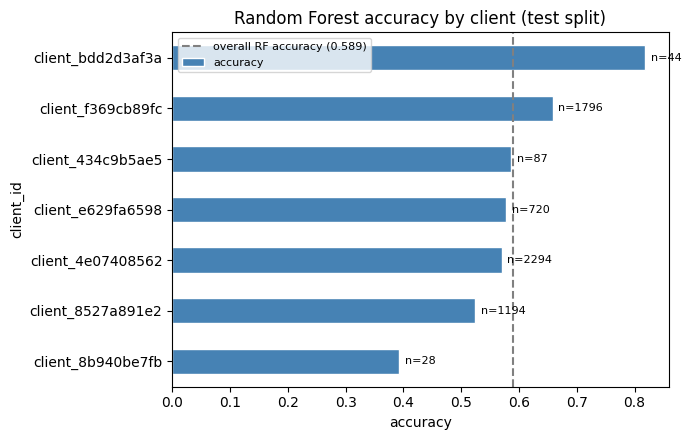

In [87]:
# --- Chart 9: accuracy by client (all test rows) ---
fig, ax = plt.subplots(figsize=(7, 4.5))
error_by_client["accuracy"].sort_values().plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
for i, (n, acc) in enumerate(zip(error_by_client.sort_values("accuracy")["n"], error_by_client.sort_values("accuracy")["accuracy"])):
    ax.text(acc + 0.01, i, f"n={n}", va="center", fontsize=8)
ax.axvline(rf_acc, linestyle="--", color="gray", label=f"overall RF accuracy ({rf_acc:.3f})")
ax.set_xlabel("accuracy")
ax.set_title("Random Forest accuracy by client (test split)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("work/outputs/w05_accuracy_by_client.png", dpi=150)
plt.show()

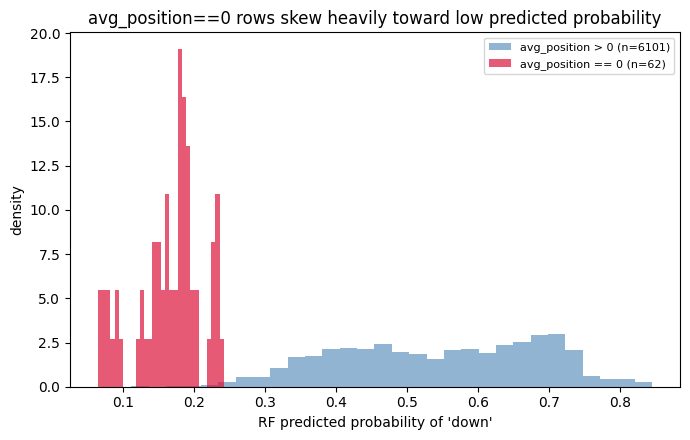

In [88]:
# --- Chart 10: avg_position=0 rows — proba distribution vs. the rest ---
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(test_results[~zero_pos_test_mask]["rf_proba"], bins=30, alpha=0.6, density=True,
        label=f"avg_position > 0 (n={(~zero_pos_test_mask).sum()})", color="steelblue")
ax.hist(zero_pos_results["rf_proba"], bins=30, alpha=0.7, density=True,
        label=f"avg_position == 0 (n={zero_pos_test_mask.sum()})", color="crimson")
ax.set_xlabel("RF predicted probability of 'down'")
ax.set_ylabel("density")
ax.set_title("avg_position==0 rows skew heavily toward low predicted probability")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("work/outputs/w05_zero_position_proba_dist.png", dpi=150)
plt.show()

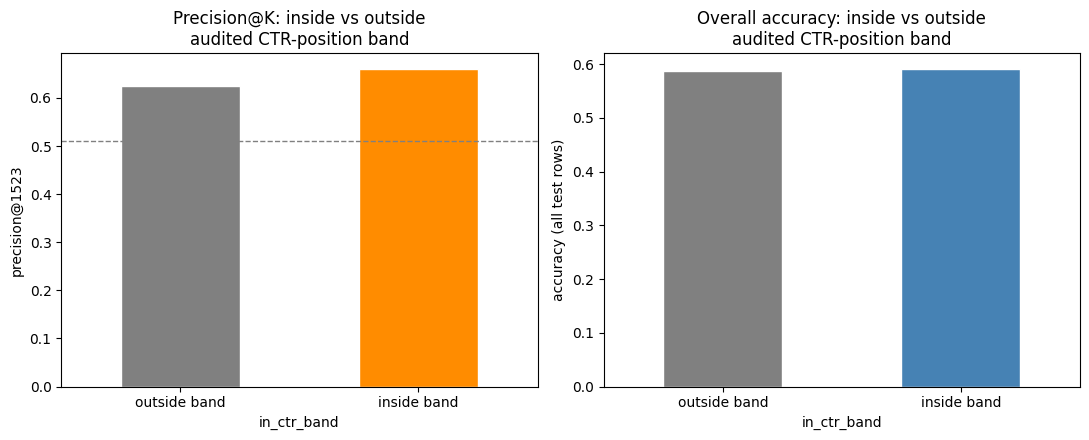

In [89]:
# --- Chart 11: summary dashboard — precision@K inside/outside band + accuracy inside/outside band, side by side ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

band_precision_at_k["mean"].plot(kind="bar", ax=axes[0], color=["gray", "darkorange"], edgecolor="white")
axes[0].set_xticklabels(["outside band", "inside band"], rotation=0)
axes[0].set_ylabel(f"precision@{K}")
axes[0].set_title("Precision@K: inside vs outside\naudited CTR-position band")
axes[0].axhline(y_test.mean(), linestyle="--", color="gray", linewidth=1)

band_accuracy["mean"].plot(kind="bar", ax=axes[1], color=["gray", "steelblue"], edgecolor="white")
axes[1].set_xticklabels(["outside band", "inside band"], rotation=0)
axes[1].set_ylabel("accuracy (all test rows)")
axes[1].set_title("Overall accuracy: inside vs outside\naudited CTR-position band")

plt.tight_layout()
plt.savefig("work/outputs/w05_band_comparison_summary.png", dpi=150)
plt.show()

### Result

**Feature reliance is legitimate.** RF's top drivers — impression history,
`avg_position`, content age — all passed Section 1's leakage sweep, and
none look suspiciously dominant (top feature = 13.2% of total importance).

**Errors are not random noise — three concrete patterns found:**

1. **One client is a genuine weak spot.** `client_8527a891e2` sits at
   0.524 accuracy (n=1,194) and 0.417 precision@K (n=297), both below
   base rate — the only sizeable client where that's true.
   `client_8b940be7fb`'s 0.393 accuracy looks worse but is n=28, too small
   to trust as a pattern rather than noise (chart: accuracy by client).

2. **The audited CTR-position band effect shows up faintly in precision@K
   (0.660 inside vs. 0.626 outside) but not in overall accuracy (0.591 vs.
   0.588, essentially flat).** The model gets a real, if modest, precision
   boost specifically where the baseline's own audited signal applies —
   consistent with RF partially recovering that interaction on top of its
   own stronger features, not ignoring it.

3. **`avg_position == 0` ("no data," not rank zero) is fed to the model as
   a literal value, never flagged as missing** — `build_feature_frame()`
   only creates `has_*` flags for actual NaNs, and this column has none.
   This is a real preprocessing gap. In practice it doesn't hurt
   performance: these 62 test rows are almost never actually "down"
   (1.6% vs. 54.2% overall), RF's predicted probability on them clusters
   correctly low (mean 0.165, visibly separated from the rest — see
   probability histogram), and accuracy on them is 98.4% vs. 58.5%
   elsewhere. The model backed into the right answer by learning "very low
   proba correlates with something," not by correctly understanding
   "no data" — a distinction worth flagging as a fix for a future
   iteration (an explicit `has_avg_position` flag) even though it isn't
   costing performance today.

**Concrete wrong cases, read individually:**
- **High-confidence false positive** (`content_3164f3076003`, proba 0.844):
  position 16.1 (inside the audited band), CTR 0.04, 88 days of impression
  history — every RF-relevant and baseline-relevant signal pointed to
  "down," and it wasn't. This is also the weak client's row — a real,
  well-supported false alarm, not an input error.
- **High-confidence false negative** (`content_7bc32bc1df59`, proba 0.153):
  `avg_position=0`, `days_with_impressions=1` — a near-brand-new,
  low-history page. Belongs to the mishandled-zero-position group above;
  one of only ~1 actual "down" case among 62 such rows, an outlier within
  a systematically low-risk group rather than a representative failure.

**Bottom line:** RF's errors concentrate in one identifiable client and
are mildly sensitive to the audited position band, both explainable and
worth flagging to a reviewer — not evidence of a broken model. The
zero-position handling gap is a real, fixable data-preparation issue for
next iteration, currently benign only by coincidence of the label's own
distribution on those rows.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

In [90]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	work/outputs/w05_accuracy_by_client.png
	work/outputs/w05_band_comparison_summary.png
	work/outputs/w05_client_down_rate_spread.png
	work/outputs/w05_confusion_matrices.png
	work/outputs/w05_leakage_scatter.png
	work/outputs/w05_precision_at_k_comparison.png
	work/outputs/w05_precision_at_varying_k.png
	work/outputs/w05_precision_recall_curve.png
	work/outputs/w05_probability_separation.png
	work/outputs/w05_rf_feature_importance.png
	work/outputs/w05_rf_precision_by_client.png
	work/outputs/w05_roc_curves.png
	work/outputs/w05_section1_distributions.png
	work/outputs/w05_split_client_row_counts.png
	work/outputs/w05_zero_position_proba_dist.png

nothing added to commit but untracked files present (use "git add" to track)


In [91]:
import subprocess

subprocess.run(["git", "add",
    "work/notebooks/w05_model.ipynb",
    "work/outputs/w05_section1_distributions.png",
    "work/outputs/w05_leakage_scatter.png",
    "work/outputs/w05_client_down_rate_spread.png",
    "work/outputs/w05_split_client_row_counts.png",
    "work/outputs/w05_roc_curves.png",
    "work/outputs/w05_confusion_matrices.png",
    "work/outputs/w05_precision_at_k_comparison.png",
    "work/outputs/w05_rf_feature_importance.png",
    "work/outputs/w05_precision_recall_curve.png",
    "work/outputs/w05_probability_separation.png",
    "work/outputs/w05_precision_at_varying_k.png",
    "work/outputs/w05_rf_precision_by_client.png",
    "work/outputs/w05_accuracy_by_client.png",
    "work/outputs/w05_zero_position_proba_dist.png",
    "work/outputs/w05_band_comparison_summary.png",
], check=True)

status = subprocess.run(["git", "status"], capture_output=True, text=True)
print(status.stdout)  # confirm only these are staged, and no CSV snuck in

On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   work/outputs/w05_accuracy_by_client.png
	new file:   work/outputs/w05_band_comparison_summary.png
	new file:   work/outputs/w05_client_down_rate_spread.png
	new file:   work/outputs/w05_confusion_matrices.png
	new file:   work/outputs/w05_leakage_scatter.png
	new file:   work/outputs/w05_precision_at_k_comparison.png
	new file:   work/outputs/w05_precision_at_varying_k.png
	new file:   work/outputs/w05_precision_recall_curve.png
	new file:   work/outputs/w05_probability_separation.png
	new file:   work/outputs/w05_rf_feature_importance.png
	new file:   work/outputs/w05_rf_precision_by_client.png
	new file:   work/outputs/w05_roc_curves.png
	new file:   work/outputs/w05_section1_distributions.png
	new file:   work/outputs/w05_split_client_row_counts.png
	new file:   work/outputs/w05_zero_position_proba_dist.png




In [93]:
!git config --global user.email "whozahm3d@gmail.com"
!git config --global user.name "Ali Ahmad"

In [94]:
result = subprocess.run(
    ["git", "commit", "-m",
     "Add w05 model: client-grouped LR/RF vs baseline, precision@K comparison, error analysis"],
    capture_output=True, text=True
)
print("returncode:", result.returncode)
print("stdout:", result.stdout)
print("stderr:", result.stderr)

returncode: 0
stdout: [main 34b32d6] Add w05 model: client-grouped LR/RF vs baseline, precision@K comparison, error analysis
 15 files changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 work/outputs/w05_accuracy_by_client.png
 create mode 100644 work/outputs/w05_band_comparison_summary.png
 create mode 100644 work/outputs/w05_client_down_rate_spread.png
 create mode 100644 work/outputs/w05_confusion_matrices.png
 create mode 100644 work/outputs/w05_leakage_scatter.png
 create mode 100644 work/outputs/w05_precision_at_k_comparison.png
 create mode 100644 work/outputs/w05_precision_at_varying_k.png
 create mode 100644 work/outputs/w05_precision_recall_curve.png
 create mode 100644 work/outputs/w05_probability_separation.png
 create mode 100644 work/outputs/w05_rf_feature_importance.png
 create mode 100644 work/outputs/w05_rf_precision_by_client.png
 create mode 100644 work/outputs/w05_roc_curves.png
 create mode 100644 work/outputs/w05_section1_distributions.png
 create mode 10